# 📊 ĐATN — Actor-Critic cho Job-Shop Scheduling

**Sinh viên**: Bạch Công Quân &nbsp;|&nbsp; **MSSV**: 1671020261  
**GVHD**: ThS. Tạ Chí Hiếu &nbsp;|&nbsp; **Lớp**: CNTT-1602

> **Hướng dẫn sử dụng notebook:**  
> 1. Chỉnh sửa **Cell 1 (CONFIG)** để trỏ đúng đường dẫn file CSV sau mỗi lần train  
> 2. **Run All** (`Kernel → Restart & Run All`) để tái tạo toàn bộ biểu đồ  
> 3. Mỗi lần train mới sẽ tự động thêm vào CSV (không xóa data cũ)

---
**Mục lục:** &nbsp;
[1. Config](#1) &nbsp;|&nbsp;
[2. Tổng quan](#2) &nbsp;|&nbsp;
[3. Learning Curves](#3) &nbsp;|&nbsp;
[4. Hội tụ](#4) &nbsp;|&nbsp;
[5. So sánh Algorithms](#5) &nbsp;|&nbsp;
[6. Gantt Chart](#6) &nbsp;|&nbsp;
[7. Thống kê](#7) &nbsp;|&nbsp;
[8. Kết luận](#8)


## ⚙️ 1. CONFIG — Chỉnh sửa tại đây <a id='1'></a>

> **Chỉnh sửa duy nhất ở cell này.** Phần còn lại chạy tự động.

In [69]:

import os
# ── Đường dẫn thư mục chứa file CSV ─────────────────────────────────────────
# Thay bằng đường dẫn tuyệt đối nếu cần, ví dụ:
# RESULTS_DIR = r"C:/Users/Quan/jssp_a2c/results"
RESULTS_DIR = r"E:/ĐATN/project/jssp_a2c_project/jssp_a2c/jssp_a2c/results"        # ← THAY ĐỔI NẾU CẦN

# ── Instance muốn phân tích ──────────────────────────────────────────────────
# Chọn 1 trong: '3x3', '4x4', '5x5', 'ft06', 'ft10'
INSTANCE = "ft06"                    # ← THAY ĐỔI NẾU CẦN

# ── Lọc theo run_id (None = lấy tất cả các lần train) ───────────────────────
# Ví dụ: RUN_IDS = [3, 4]  → chỉ lấy lần train thứ 3 và 4
# Ví dụ: RUN_IDS = None    → lấy toàn bộ mọi lần train
RUN_IDS = None                      # ← THAY ĐỔI NẾU CẦN

# ── Lấy run mới nhất để vẽ Gantt ─────────────────────────────────────────────
# True  = chỉ dùng run mới nhất để vẽ Gantt + so sánh chính
# False = dùng run tốt nhất (makespan thấp nhất)
USE_LATEST_RUN = True               # ← THAY ĐỔI NẾU CẦN

# ── Đường dẫn file CSV (tự động tạo từ RESULTS_DIR + INSTANCE) ──────────────
TRAINING_LOG_CSV = os.path.join(RESULTS_DIR, f"training_log_{INSTANCE}.csv")
EVALUATION_CSV   = os.path.join(RESULTS_DIR, f"evaluation_{INSTANCE}.csv")

def schedule_csv(algo: str) -> str:
    """Đường dẫn file schedule CSV cho 1 algorithm."""
    return os.path.join(RESULTS_DIR, f"schedule_{INSTANCE}_{algo}.csv")

# ── Kiểm tra file tồn tại ─────────────────────────────────────────────────────
print("✅ CONFIG loaded!")
print(f"   RESULTS_DIR      : {os.path.abspath(RESULTS_DIR)}")
print(f"   INSTANCE         : {INSTANCE}")
print(f"   RUN_IDS filter   : {RUN_IDS if RUN_IDS else 'Tất cả'}")
print(f"   USE_LATEST_RUN   : {USE_LATEST_RUN}")
print()

missing = []
for label, path in [("training_log", TRAINING_LOG_CSV), ("evaluation", EVALUATION_CSV)]:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ KHÔNG TÌM THẤY"
    print(f"   {status}  {label}: {os.path.basename(path)}")
    if not exists:
        missing.append(path)

if missing:
    print()
    print("⚠️  Hãy chạy training trước:")
    print("   python train_numpy.py --instance", INSTANCE)


✅ CONFIG loaded!
   RESULTS_DIR      : E:\ĐATN\project\jssp_a2c_project\jssp_a2c\jssp_a2c\results
   INSTANCE         : ft06
   RUN_IDS filter   : Tất cả
   USE_LATEST_RUN   : True

   ✅  training_log: training_log_ft06.csv
   ✅  evaluation: evaluation_ft06.csv


## 📦 2. Setup & Tổng quan dữ liệu <a id='2'></a>

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi':120, 'font.size':11,
                     'axes.titlesize':13, 'figure.facecolor':'white'})

ALGO_COLORS = {
    'a2c':'#2196F3','fifo':'#FF9800','spt':'#4CAF50',
    'lpt':'#9C27B0','edd':'#F44336','random':'#607D8B',
}
ALGO_LABELS = {
    'a2c':'A2C (Actor-Critic)','fifo':'FIFO',
    'spt':'SPT','lpt':'LPT','edd':'EDD','random':'Random',
}
JOB_COLORS = ['#4f8ef7','#34d399','#fb923c','#f472b6','#a78bfa','#fbbf24']

# ── Load CSV ──────────────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAINING_LOG_CSV)
eval_df  = pd.read_csv(EVALUATION_CSV)

# Ép kiểu
train_df['run_id']    = train_df['run_id'].astype(int)
train_df['trained_at']= pd.to_datetime(train_df['trained_at'])
eval_df['run_id']     = eval_df['run_id'].astype(int)
eval_df['trained_at'] = pd.to_datetime(eval_df['trained_at'])

# ── Lọc theo RUN_IDS nếu được chỉ định ───────────────────────────────────────
if RUN_IDS is not None:
    train_df = train_df[train_df['run_id'].isin(RUN_IDS)]
    eval_df  = eval_df[eval_df['run_id'].isin(RUN_IDS)]

ALL_RUN_IDS  = sorted(train_df['run_id'].unique())
LATEST_RUN   = ALL_RUN_IDS[-1]
BEST_RUN     = train_df.groupby('run_id')['best_makespan'].min().idxmin()
SELECTED_RUN = LATEST_RUN if USE_LATEST_RUN else BEST_RUN

print("=" * 55)
print(f"  TỔNG QUAN DỮ LIỆU — Instance: {INSTANCE.upper()}")
print("=" * 55)
print(f"  Tổng số lần train : {len(ALL_RUN_IDS)}")
print(f"  Run IDs           : {ALL_RUN_IDS}")
print(f"  Run mới nhất      : #{LATEST_RUN}")
print(f"  Run tốt nhất      : #{BEST_RUN}")
print(f"  Run đang phân tích: #{SELECTED_RUN}")
print()

summary = train_df.groupby('run_id').agg(
    trained_at   = ('trained_at','first'),
    n_episodes   = ('episode','max'),
    best_makespan= ('best_makespan','min'),
    mean_reward  = ('reward','mean'),
).round(2)
print(summary.to_string())


  TỔNG QUAN DỮ LIỆU — Instance: FT06
  Tổng số lần train : 7
  Run IDs           : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  Run mới nhất      : #7
  Run tốt nhất      : #4
  Run đang phân tích: #7

                trained_at  n_episodes  best_makespan  mean_reward
run_id                                                            
1      2026-05-19 01:50:54        3500          68.83       -69.11
2      2026-05-19 01:54:45        5000          68.67       -57.34
3      2026-05-19 14:22:15        5000          68.67       -57.34
4      2026-05-19 23:06:41        6000          63.50       -51.88
5      2026-05-19 23:31:35        6500          65.33       -45.58
6      2026-05-20 23:48:21        6500          65.33       -45.58
7      2026-05-26 18:59:20        3000          78.33       -71.47


In [71]:
# Hiển thị 5 dòng đầu của từng CSV
print("── training_log (5 dòng đầu) ──")
display(train_df.head())
print()
print("── evaluation (5 dòng đầu) ──")
display(eval_df.head())


── training_log (5 dòng đầu) ──


,run_id,trained_at,instance,n_episodes,episode,reward,makespan,avg_reward_100,critic_loss,entropy,entropy_coef,best_makespan,is_best,rolling_eval_ms
0,1,2026-05-19 01:50:54,ft06,3500,1,-136.7035,113,-136.7035,545.833753,1.431355,0.049971,inf,0,-1.0
1,1,2026-05-19 01:50:54,ft06,3500,2,-78.2732,97,-107.4884,195.900283,1.469238,0.049943,inf,0,-1.0
2,1,2026-05-19 01:50:54,ft06,3500,3,-146.5652,115,-120.5140,590.890207,1.419933,0.049914,inf,0,-1.0
3,1,2026-05-19 01:50:54,ft06,3500,4,-135.4404,109,-124.2456,677.559377,1.510303,0.049885,inf,0,-1.0
4,1,2026-05-19 01:50:54,ft06,3500,5,-95.5208,96,-118.5006,229.844694,1.509993,0.049857,inf,0,-1.0



── evaluation (5 dòng đầu) ──


,run_id,trained_at,instance,algorithm,run,makespan,idle_time,utilization
0,1,2026-05-19 01:50:54,ft06,a2c,1,81,289,0.4053
1,1,2026-05-19 01:50:54,ft06,a2c,2,75,253,0.4378
2,1,2026-05-19 01:50:54,ft06,a2c,3,77,265,0.4264
3,1,2026-05-19 01:50:54,ft06,a2c,4,72,235,0.4560
4,1,2026-05-19 01:50:54,ft06,a2c,5,67,205,0.4900


## 📈 3. Learning Curves <a id='3'></a>

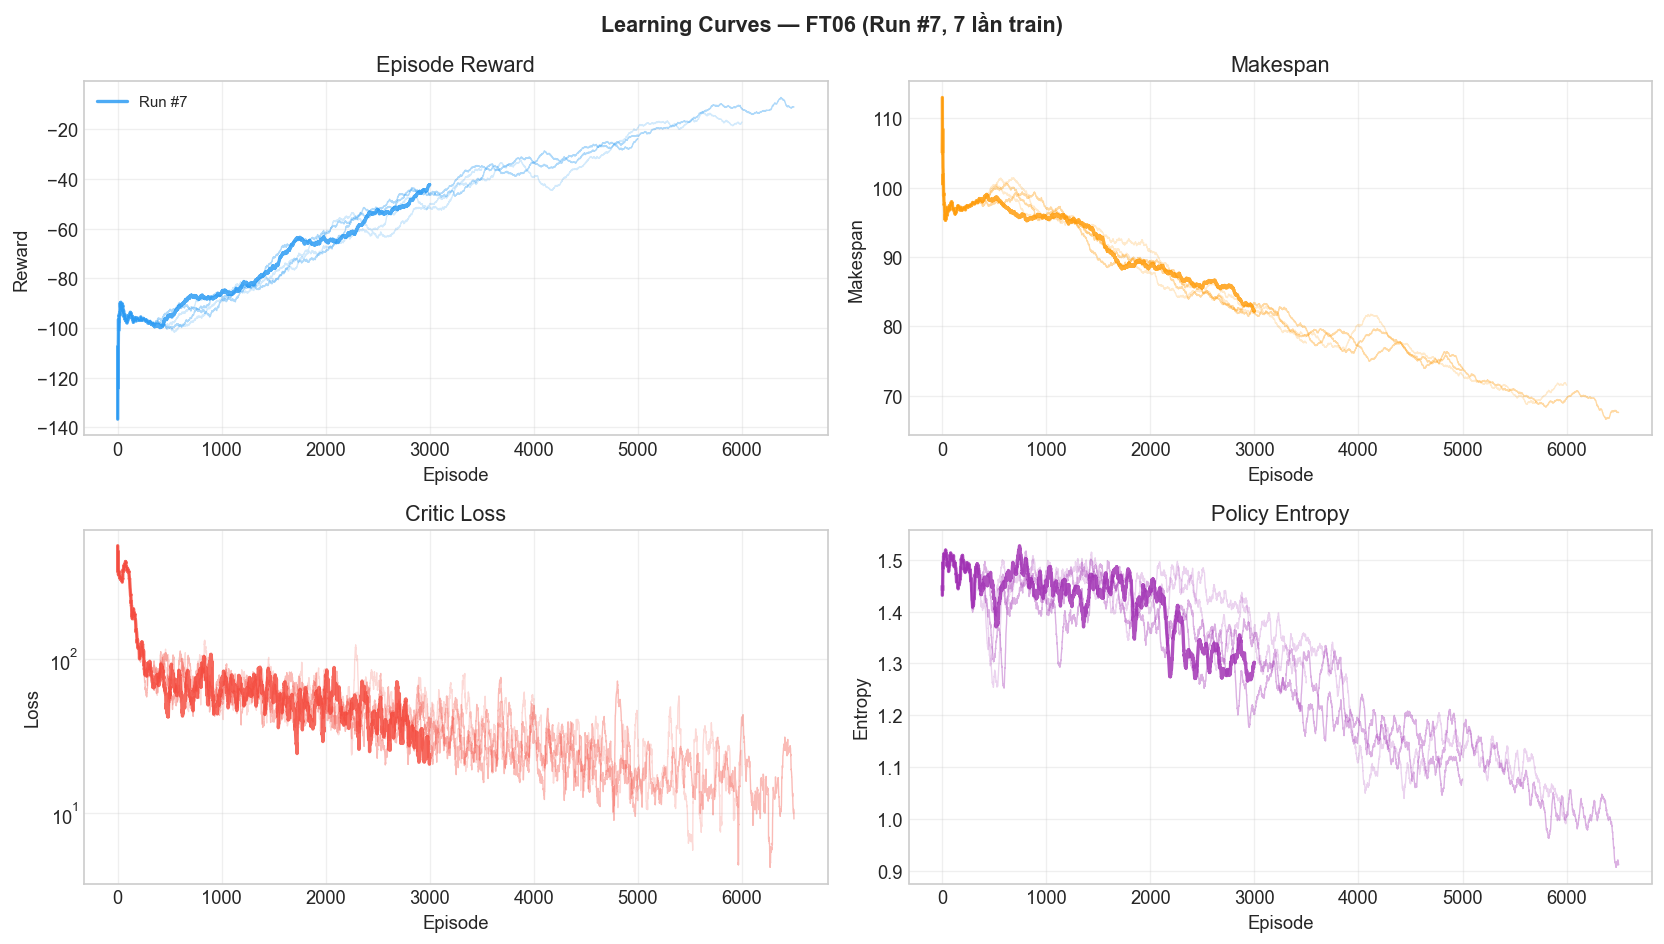

✅ Saved: nb_01_learning_curves.png


In [72]:
def moving_avg(s: pd.Series, w: int) -> pd.Series:
    return s.rolling(window=w, min_periods=1).mean()

WINDOW = max(10, len(train_df[train_df['run_id']==SELECTED_RUN]) // 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(
    f'Learning Curves — {INSTANCE.upper()} '
    f'(Run #{SELECTED_RUN}, {len(ALL_RUN_IDS)} lần train)',
    fontsize=13, fontweight='bold'
)

# Vẽ TẤT CẢ các run (mờ) rồi highlight run được chọn
for run_id, grp in train_df.groupby('run_id'):
    alpha  = 0.8 if run_id == SELECTED_RUN else 0.2
    lw     = 2.0 if run_id == SELECTED_RUN else 0.8
    label  = f'Run #{run_id}' if run_id == SELECTED_RUN else None

    axes[0,0].plot(grp['episode'], moving_avg(grp['reward'], WINDOW),
                   alpha=alpha, lw=lw, label=label, color='#2196F3')
    axes[0,1].plot(grp['episode'], moving_avg(grp['makespan'], WINDOW),
                   alpha=alpha, lw=lw, color='#FF9800')
    axes[1,0].plot(grp['episode'], moving_avg(grp['critic_loss'].replace(0,np.nan).fillna(method='ffill'), 30),
                   alpha=alpha, lw=lw, color='#F44336')
    axes[1,1].plot(grp['episode'], moving_avg(grp['entropy'], 30),
                   alpha=alpha, lw=lw, color='#9C27B0')

for ax, title, ylabel in zip(
    axes.flatten(),
    ['Episode Reward','Makespan','Critic Loss','Policy Entropy'],
    ['Reward','Makespan','Loss','Entropy']
):
    ax.set_title(title); ax.set_xlabel('Episode'); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

axes[0,0].legend(fontsize=9)
axes[1,0].set_yscale('log')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_01_learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: nb_01_learning_curves.png")


## 🔍 4. Phân tích hội tụ <a id='4'></a>

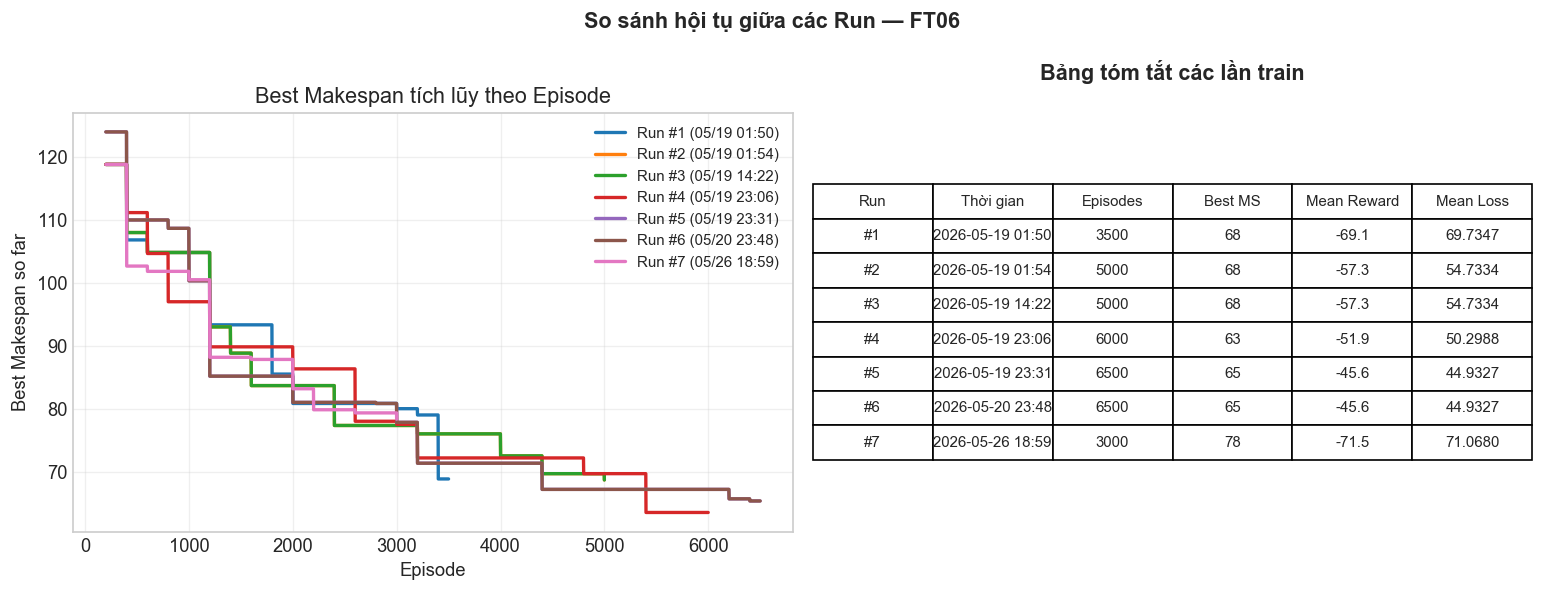

In [73]:
# ── So sánh hội tụ giữa các lần train ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'So sánh hội tụ giữa các Run — {INSTANCE.upper()}',
             fontsize=13, fontweight='bold')

# Best makespan đạt được theo episode (cumulative min)
ax = axes[0]
for run_id, grp in train_df.groupby('run_id'):
    ts = grp['trained_at'].iloc[0].strftime('%m/%d %H:%M')
    ax.plot(grp['episode'], grp['best_makespan'],
            label=f'Run #{run_id} ({ts})', linewidth=2)
ax.set_title('Best Makespan tích lũy theo Episode')
ax.set_xlabel('Episode'); ax.set_ylabel('Best Makespan so far')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Bảng so sánh các run
ax = axes[1]
ax.axis('off')

table_data = []
for run_id, grp in train_df.groupby('run_id'):
    table_data.append([
        f'#{run_id}',
        grp['trained_at'].iloc[0].strftime('%Y-%m-%d %H:%M'),
        str(int(grp['episode'].max())),
        str(int(grp['best_makespan'].min())),
        f"{grp['reward'].mean():.1f}",
        f"{grp['critic_loss'].mean():.4f}",
    ])

tbl = ax.table(
    cellText=table_data,
    colLabels=['Run','Thời gian','Episodes','Best MS','Mean Reward','Mean Loss'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.9)
ax.set_title('Bảng tóm tắt các lần train', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_02_convergence.png', bbox_inches='tight', dpi=150)
plt.show()


## 🏆 5. So sánh Algorithms <a id='5'></a>

In [74]:
# Dùng evaluation của SELECTED_RUN để so sánh
eval_sel = eval_df[eval_df['run_id'] == SELECTED_RUN]
algos    = ['a2c','fifo','spt','lpt','edd','random']
labels   = [ALGO_LABELS.get(a, a.upper()) for a in algos]
colors   = [ALGO_COLORS.get(a, '#999') for a in algos]

print(f"Evaluation — Run #{SELECTED_RUN} ({INSTANCE.upper()})")
print(eval_sel.groupby('algorithm').agg(
    Mean=('makespan','mean'), Std=('makespan','std'),
    Best=('makespan','min'), Util=('utilization','mean')
).round(2).sort_values('Mean').to_string())


Evaluation — Run #7 (FT06)
              Mean    Std  Best  Util
algorithm                            
a2c_greedy   75.00    NaN    75  0.44
a2c          78.60   7.18    65  0.42
random       98.63  13.94    70  0.34
edd         101.00    NaN   101  0.33
spt         109.00    NaN   109  0.30
lpt         129.00    NaN   129  0.25
fifo        152.00    NaN   152  0.22


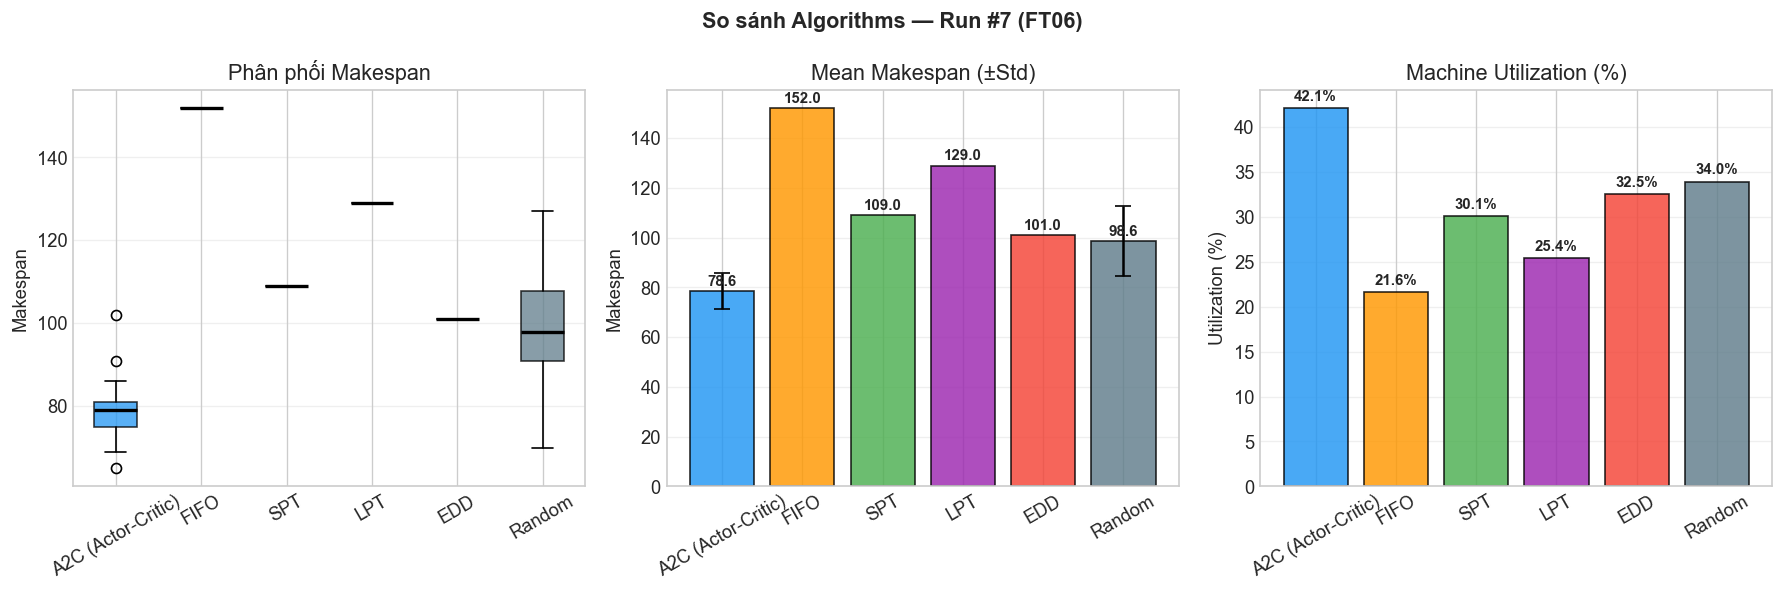

✅ Saved: nb_03_evaluation.png


In [75]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'So sánh Algorithms — Run #{SELECTED_RUN} ({INSTANCE.upper()})',
             fontsize=13, fontweight='bold')

# Box plot
ax = axes[0]
data = [eval_sel[eval_sel['algorithm']==a]['makespan'].values for a in algos]
bp   = ax.boxplot(data, patch_artist=True, labels=labels,
                  medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_title('Phân phối Makespan'); ax.set_ylabel('Makespan')
ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)

# Bar mean
ax = axes[1]
means = [eval_sel[eval_sel['algorithm']==a]['makespan'].mean() for a in algos]
stds  = [eval_sel[eval_sel['algorithm']==a]['makespan'].std()  for a in algos]
bars  = ax.bar(labels, means, yerr=stds, capsize=5,
               color=colors, alpha=0.82, edgecolor='black')
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{m:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Mean Makespan (±Std)'); ax.set_ylabel('Makespan')
ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)

# Utilization
ax = axes[2]
utils = [eval_sel[eval_sel['algorithm']==a]['utilization'].mean()*100 for a in algos]
bars  = ax.bar(labels, utils, color=colors, alpha=0.82, edgecolor='black')
for bar, u in zip(bars, utils):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{u:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Machine Utilization (%)'); ax.set_ylabel('Utilization (%)')
ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_03_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: nb_03_evaluation.png")


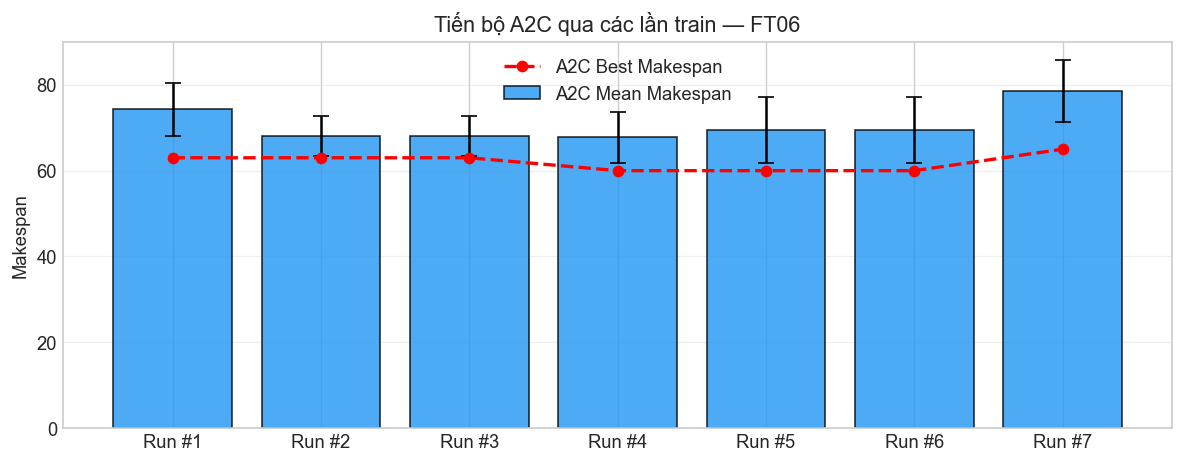

✅ Saved: nb_04_a2c_progress.png


In [76]:
# ── So sánh A2C qua nhiều lần train (nếu có > 1 run) ─────────────────────────
if len(ALL_RUN_IDS) > 1:
    fig, ax = plt.subplots(figsize=(10, 4))
    a2c_by_run = eval_df[eval_df['algorithm']=='a2c'].groupby('run_id').agg(
        mean_ms=('makespan','mean'), std_ms=('makespan','std'),
        best_ms=('makespan','min')
    ).reset_index()
    x = range(len(a2c_by_run))
    ax.bar(x, a2c_by_run['mean_ms'], yerr=a2c_by_run['std_ms'],
           capsize=5, color='#2196F3', alpha=0.8, edgecolor='black',
           label='A2C Mean Makespan')
    ax.plot(x, a2c_by_run['best_ms'], 'r--o', lw=2, label='A2C Best Makespan')
    ax.set_xticks(x)
    ax.set_xticklabels([f'Run #{r}' for r in a2c_by_run['run_id']])
    ax.set_title(f'Tiến bộ A2C qua các lần train — {INSTANCE.upper()}')
    ax.set_ylabel('Makespan'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/nb_04_a2c_progress.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("✅ Saved: nb_04_a2c_progress.png")
else:
    print("ℹ️  Chỉ có 1 run — Train thêm lần nữa để thấy biểu đồ tiến bộ này.")


## 📅 6. Gantt Chart <a id='6'></a>

In [77]:
def plot_gantt_from_csv(algo: str, ax, title: str, run_id_filter=None):
    """Vẽ Gantt chart từ schedule_{INSTANCE}_{algo}.csv."""
    df = pd.read_csv(schedule_csv(algo))
    df['run_id'] = df['run_id'].astype(int)

    # Lọc run_id
    if run_id_filter is not None:
        df = df[df['run_id'] == run_id_filter]
    else:
        # Lấy run mới nhất trong file schedule
        df = df[df['run_id'] == df['run_id'].max()]

    n_machines = df['machine'].max() + 1
    makespan   = df['end'].max()

    for _, row in df.iterrows():
        color = JOB_COLORS[int(row['job']) % len(JOB_COLORS)]
        ax.barh(row['machine'], row['duration'], left=row['start'],
                color=color, edgecolor='black', linewidth=0.6, height=0.65)
        if row['duration'] > makespan * 0.04:
            ax.text(row['start']+row['duration']/2, row['machine'],
                    f"J{int(row['job'])}", ha='center', va='center',
                    fontsize=8, fontweight='bold')

    ax.axvline(makespan, color='red', linestyle='--', lw=2, label=f'Makespan={makespan}')
    ax.set_yticks(range(n_machines))
    ax.set_yticklabels([f'M{m}' for m in range(n_machines)])
    ax.set_xlabel('Time'); ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9); ax.grid(axis='x', alpha=0.3)
    return df['job'].max() + 1


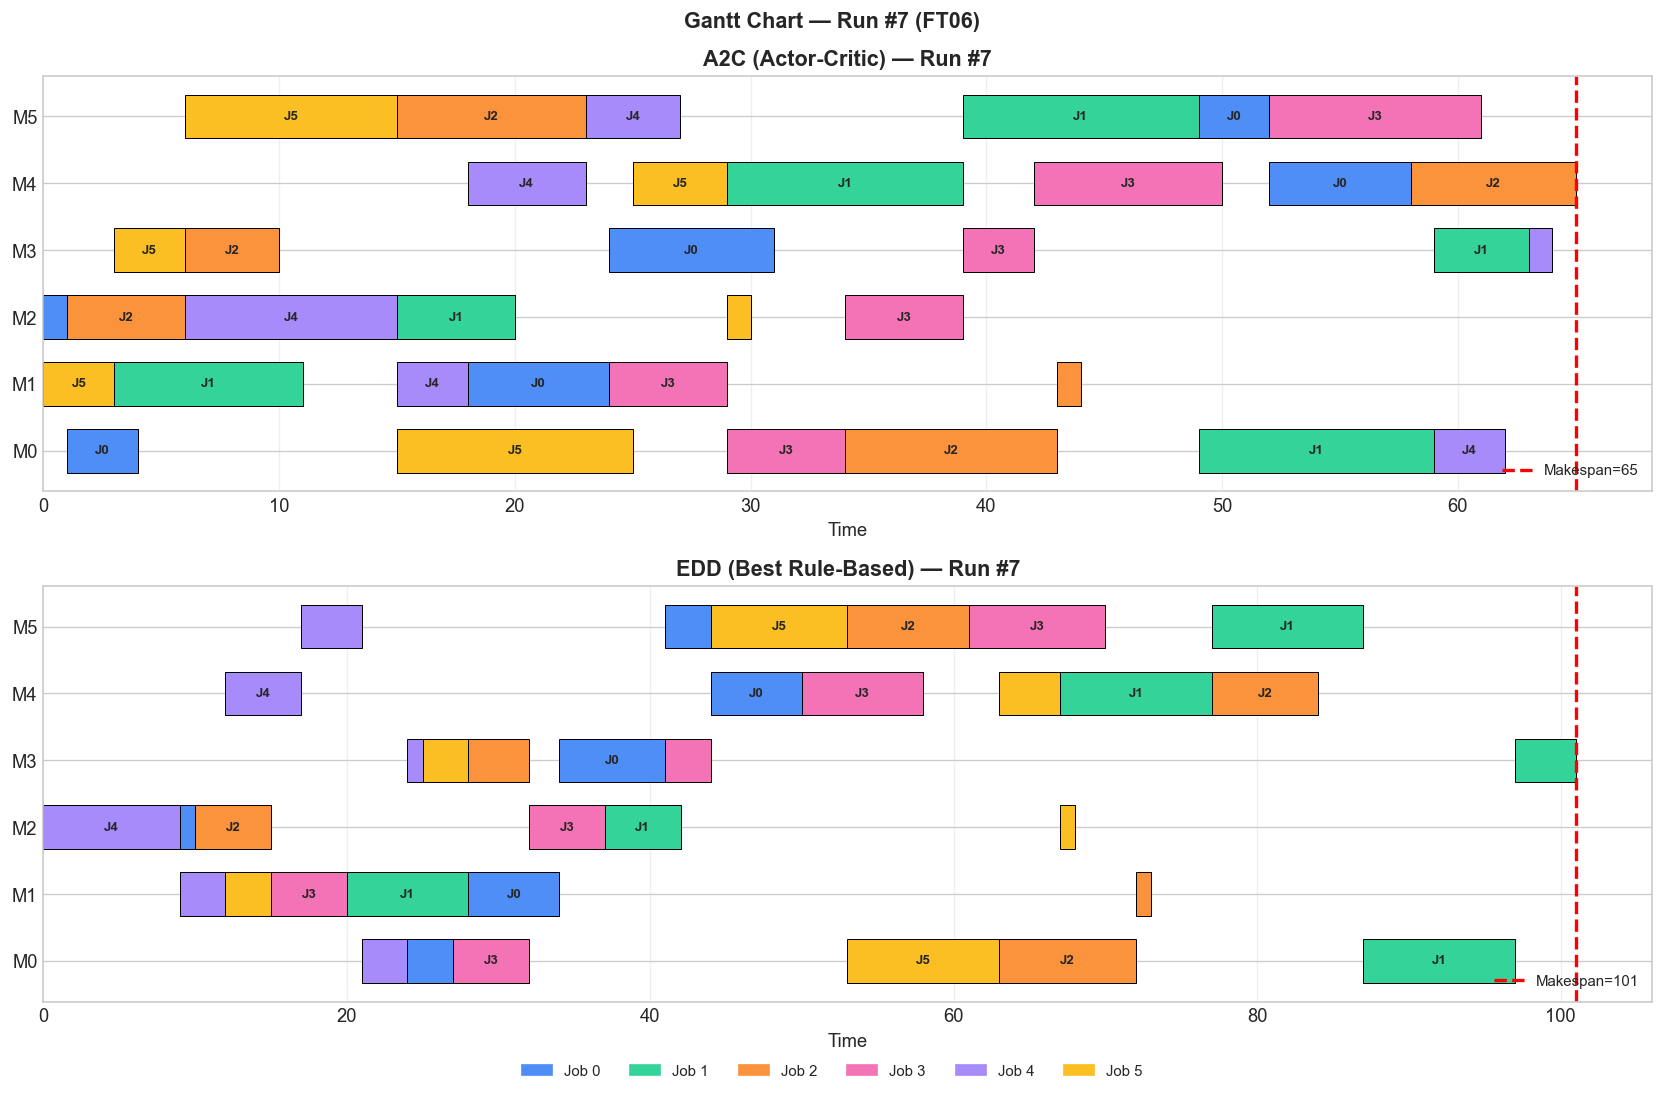

✅ Saved: nb_05_gantt_a2c_vs_edd.png


In [78]:
# Vẽ A2C vs EDD song song
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle(f'Gantt Chart — Run #{SELECTED_RUN} ({INSTANCE.upper()})',
             fontsize=13, fontweight='bold')

n_jobs = plot_gantt_from_csv('a2c', axes[0],
    f'A2C (Actor-Critic) — Run #{SELECTED_RUN}', run_id_filter=SELECTED_RUN)
plot_gantt_from_csv('edd', axes[1],
    f'EDD (Best Rule-Based) — Run #{SELECTED_RUN}', run_id_filter=SELECTED_RUN)

patches = [mpatches.Patch(color=JOB_COLORS[j], label=f'Job {j}') for j in range(n_jobs)]
fig.legend(handles=patches, loc='lower center', ncol=n_jobs,
           fontsize=9, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_05_gantt_a2c_vs_edd.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: nb_05_gantt_a2c_vs_edd.png")


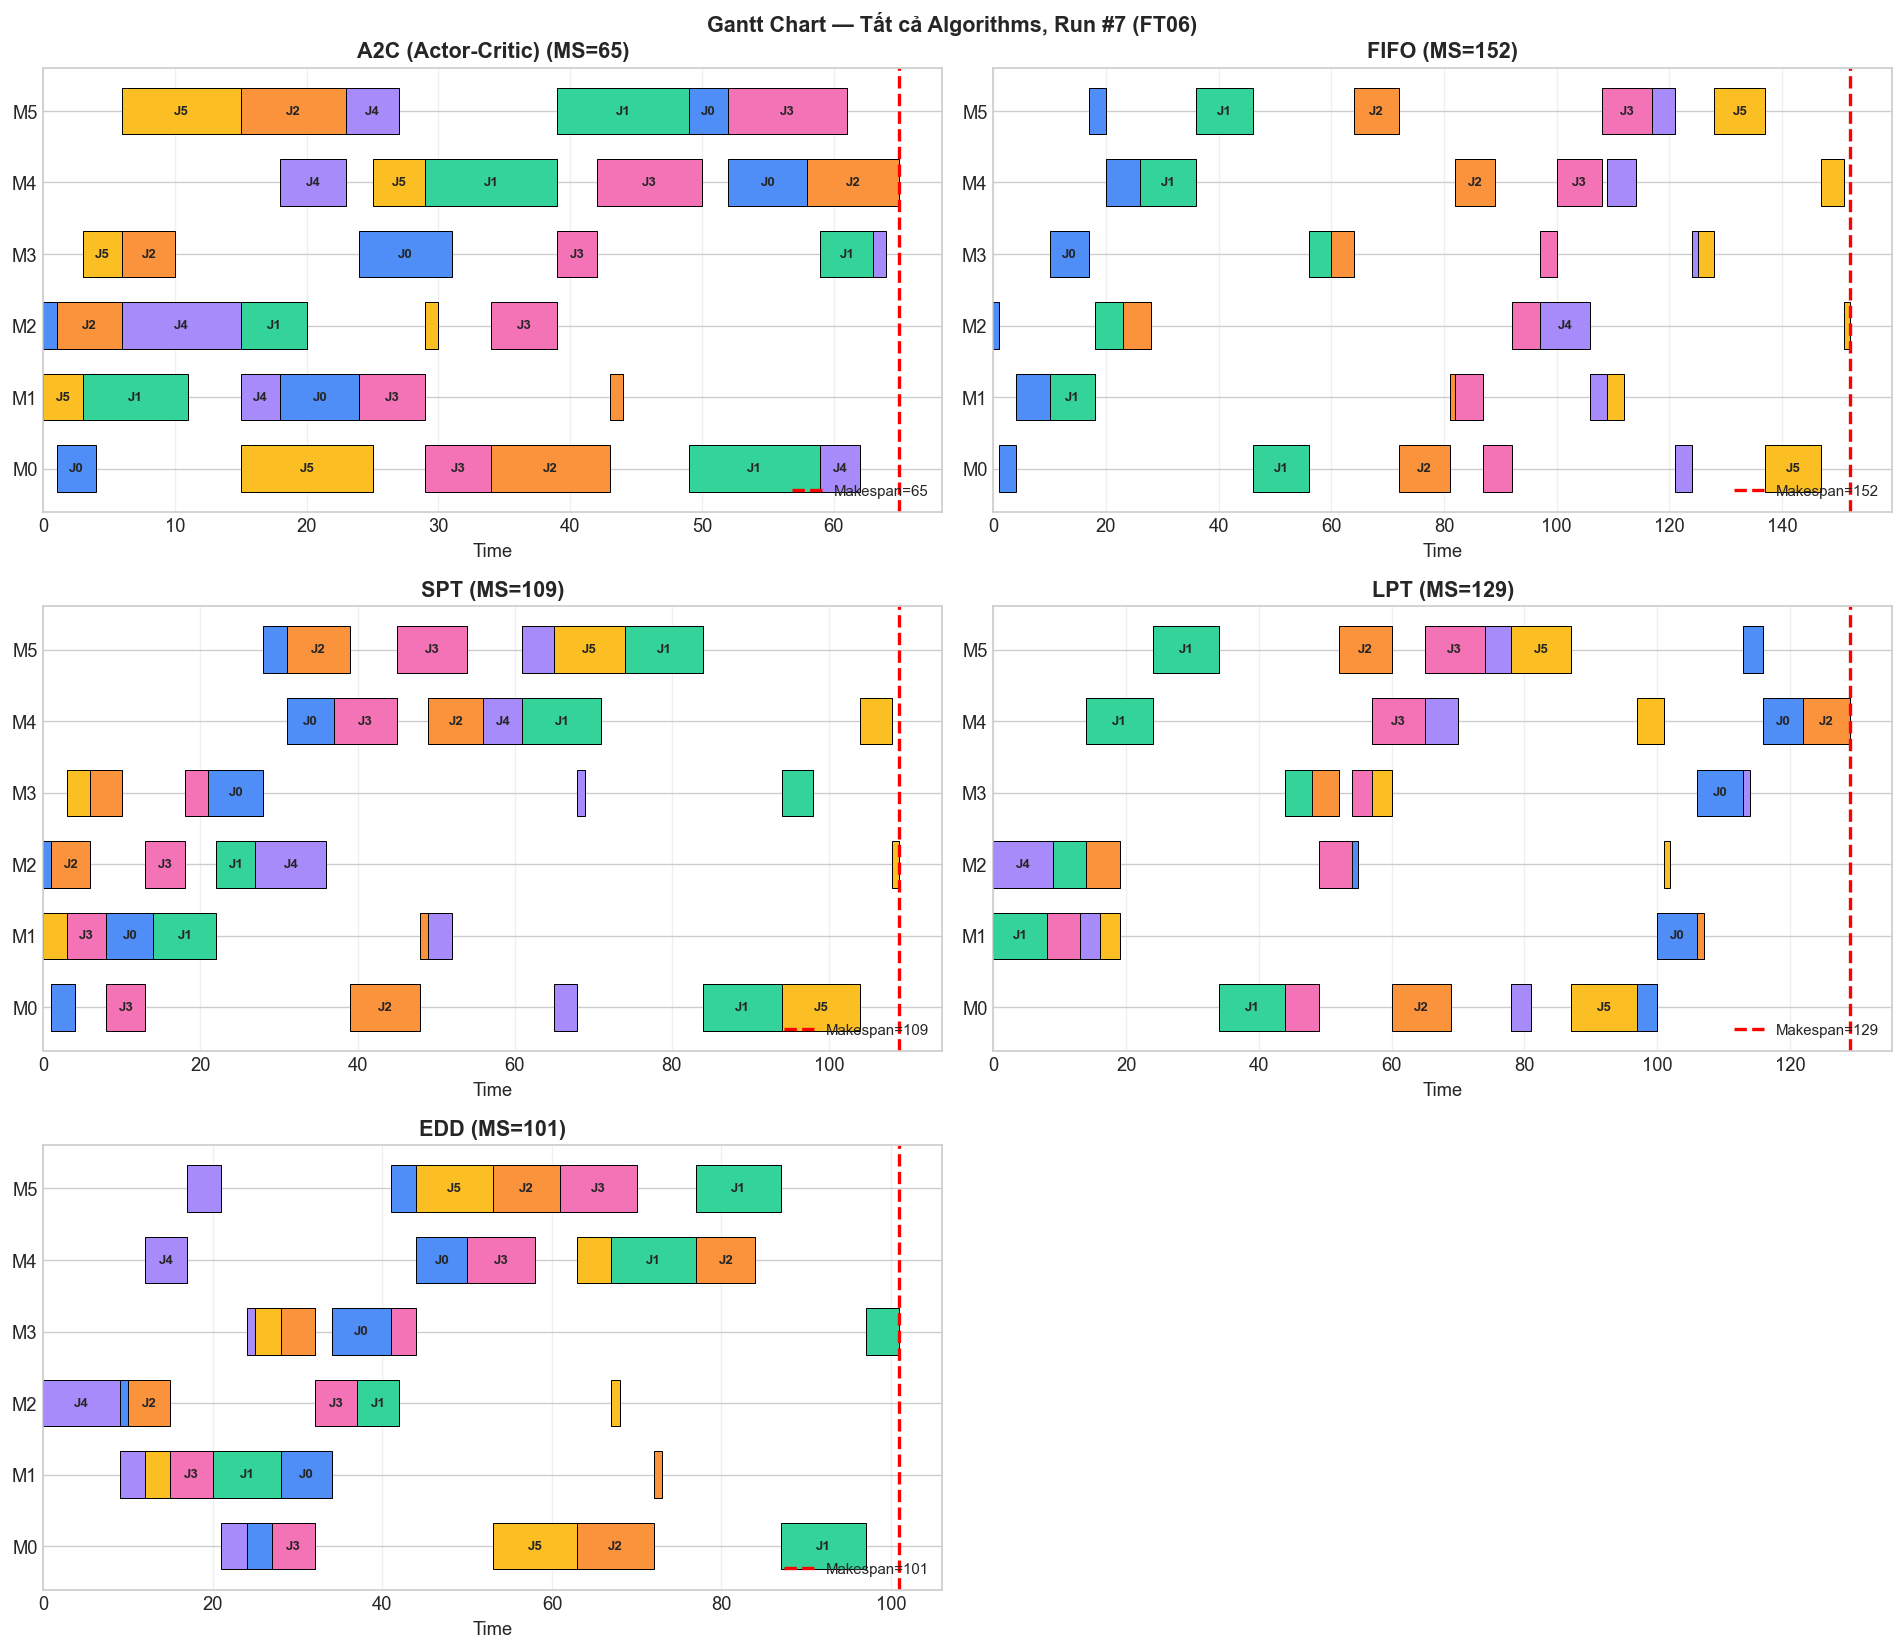

In [79]:
# Gantt tất cả algorithms (grid 3x2)
plot_algos = ['a2c','fifo','spt','lpt','edd']
fig, axes  = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(f'Gantt Chart — Tất cả Algorithms, Run #{SELECTED_RUN} ({INSTANCE.upper()})',
             fontsize=13, fontweight='bold')

for ax, algo in zip(axes.flatten()[:5], plot_algos):
    df_s = pd.read_csv(schedule_csv(algo))
    df_s['run_id'] = df_s['run_id'].astype(int)
    df_s = df_s[df_s['run_id'] == df_s['run_id'].max()]
    ms   = df_s['end'].max()
    plot_gantt_from_csv(algo, ax, f'{ALGO_LABELS[algo]} (MS={ms})')

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_06_gantt_all.png', bbox_inches='tight', dpi=150)
plt.show()


## 📐 7. Phân tích thống kê <a id='7'></a>

In [80]:
from scipy import stats

eval_sel = eval_df[eval_df['run_id'] == SELECTED_RUN]
a2c_ms   = eval_sel[eval_sel['algorithm']=='a2c']['makespan'].values

print("Wilcoxon Signed-Rank Test (H₁: A2C < Baseline, α=0.05)")
print(f"{'Algorithm':<10} {'A2C mean':>10} {'BL mean':>10} {'p-value':>10} {'Kết luận':>20} {'Δ%':>8}")
print("─"*65)

for algo in ['fifo','spt','lpt','edd','random']:
    bl   = eval_sel[eval_sel['algorithm']==algo]['makespan'].values
    n    = min(len(a2c_ms), len(bl))
    try:
        _, p = stats.wilcoxon(a2c_ms[:n], bl[:n], alternative='less')
    except:
        p = 1.0
    sig   = "✅ Tốt hơn" if p < 0.05 else "❌ Không rõ"
    delta = (bl.mean() - a2c_ms.mean()) / bl.mean() * 100
    print(f"{algo.upper():<10} {a2c_ms.mean():>10.2f} {bl.mean():>10.2f} "
          f"{p:>10.4f} {sig:>20} {delta:>+7.1f}%")


Wilcoxon Signed-Rank Test (H₁: A2C < Baseline, α=0.05)
Algorithm    A2C mean    BL mean    p-value             Kết luận       Δ%
─────────────────────────────────────────────────────────────────
FIFO            78.60     152.00     0.5000           ❌ Không rõ   +48.3%
SPT             78.60     109.00     0.5000           ❌ Không rõ   +27.9%
LPT             78.60     129.00     0.5000           ❌ Không rõ   +39.1%
EDD             78.60     101.00     0.5000           ❌ Không rõ   +22.2%
RANDOM          78.60      98.63     0.0000            ✅ Tốt hơn   +20.3%


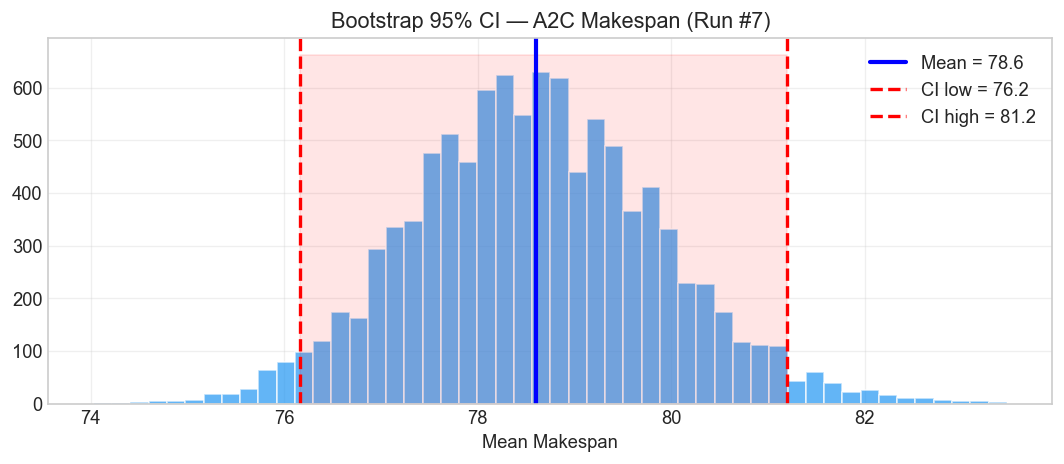

95% CI: [76.17, 81.20]  — Width = 5.03


In [81]:
# Bootstrap CI cho A2C
np.random.seed(42)
boots = [np.random.choice(a2c_ms, len(a2c_ms), replace=True).mean()
         for _ in range(10000)]
ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(boots, bins=50, color='#2196F3', alpha=0.7, edgecolor='white')
ax.axvline(a2c_ms.mean(), color='blue',  lw=2.5, label=f'Mean = {a2c_ms.mean():.1f}')
ax.axvline(ci_lo,         color='red',   lw=2,   linestyle='--', label=f'CI low = {ci_lo:.1f}')
ax.axvline(ci_hi,         color='red',   lw=2,   linestyle='--', label=f'CI high = {ci_hi:.1f}')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                 ci_lo, ci_hi, alpha=0.1, color='red')
ax.set_title(f'Bootstrap 95% CI — A2C Makespan (Run #{SELECTED_RUN})')
ax.set_xlabel('Mean Makespan'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/nb_07_bootstrap_ci.png', bbox_inches='tight', dpi=150)
plt.show()
print(f"95% CI: [{ci_lo:.2f}, {ci_hi:.2f}]  — Width = {ci_hi-ci_lo:.2f}")


## 📝 8. Kết luận <a id='8'></a>

In [82]:
eval_sel   = eval_df[eval_df['run_id'] == SELECTED_RUN]
a2c_mean   = eval_sel[eval_sel['algorithm']=='a2c']['makespan'].mean()
a2c_best   = eval_sel[eval_sel['algorithm']=='a2c']['makespan'].min()
fifo_mean  = eval_sel[eval_sel['algorithm']=='fifo']['makespan'].mean()
best_rule  = eval_sel[eval_sel['algorithm'].isin(['fifo','spt','lpt','edd'])
                     ].groupby('algorithm')['makespan'].mean().idxmin()
best_rule_ms = eval_sel[eval_sel['algorithm']==best_rule]['makespan'].mean()

print("=" * 55)
print(f"  KẾT QUẢ — {INSTANCE.upper()} | Run #{SELECTED_RUN}")
print("=" * 55)
print(f"  A2C mean makespan   : {a2c_mean:.2f}")
print(f"  A2C best makespan   : {a2c_best:.0f}")
print(f"  FIFO mean           : {fifo_mean:.2f}")
print(f"  Best rule ({best_rule.upper()}) : {best_rule_ms:.2f}")
print(f"  A2C vs FIFO         : {(fifo_mean-a2c_mean)/fifo_mean*100:+.1f}%")
print(f"  A2C vs Best Rule    : {(best_rule_ms-a2c_mean)/best_rule_ms*100:+.1f}%")
print()
print("  Tất cả charts đã lưu vào RESULTS_DIR:")
import glob
for f in sorted(glob.glob(f'{RESULTS_DIR}/nb_*.png')):
    print(f"    📊 {os.path.basename(f)}")


  KẾT QUẢ — FT06 | Run #7
  A2C mean makespan   : 78.60
  A2C best makespan   : 65
  FIFO mean           : 152.00
  Best rule (EDD) : 101.00
  A2C vs FIFO         : +48.3%
  A2C vs Best Rule    : +22.2%

  Tất cả charts đã lưu vào RESULTS_DIR:
    📊 nb_01_learning_curves.png
    📊 nb_02_convergence.png
    📊 nb_03_evaluation.png
    📊 nb_04_a2c_progress.png
    📊 nb_05_gantt_a2c_vs_edd.png
    📊 nb_06_gantt_all.png
    📊 nb_07_bootstrap_ci.png
